<a href="https://colab.research.google.com/github/annisafadila/1320123001-data-mining/blob/main/Tugas_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Informasi Project

Dataset: Mall Customers Dataset
Jumlah data: 200 pelanggan
Tujuan: Melakukan segmentasi pelanggan menggunakan teknik clustering (K-Means)

2. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

3. Membuat & Load Dataset

In [6]:
np.random.seed(42)


data = pd.DataFrame({
'CustomerID': range(1, 201),
'Gender': np.random.choice(['Male', 'Female'], 200),
'Age': np.random.randint(18, 70, 200),
'Annual Income (k$)': np.random.randint(15, 140, 200),
'Spending Score (1-100)': np.random.randint(1, 101, 200)
})


data.to_csv('mall_customers.csv', index=False)


data = pd.read_csv('mall_customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,49,68,86
1,2,Female,56,22,57
2,3,Male,66,41,29
3,4,Male,69,41,78
4,5,Male,49,112,92


4. Exploratory Data Analysis (EDA)

In [7]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,44.405000,77.035000,51.200000
std,57.879185,15.353816,36.558397,29.816019
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,32.750000,44.000000,24.000000
50%,100.500000,46.000000,74.000000,50.000000
75%,150.250000,56.000000,111.000000,76.500000
max,200.000000,69.000000,139.000000,100.000000


4.2 Distribusi Gender

In [8]:
data['Gender'].value_counts()

,count
Gender,
Male,100
Female,100


4.3 Distribusi Usia

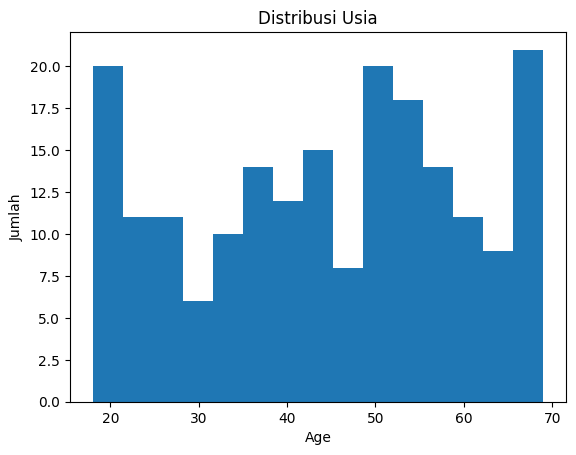

In [9]:
plt.hist(data['Age'], bins=15)
plt.title('Distribusi Usia')
plt.xlabel('Age')
plt.ylabel('Jumlah')
plt.show()

4.4 Distribusi Income

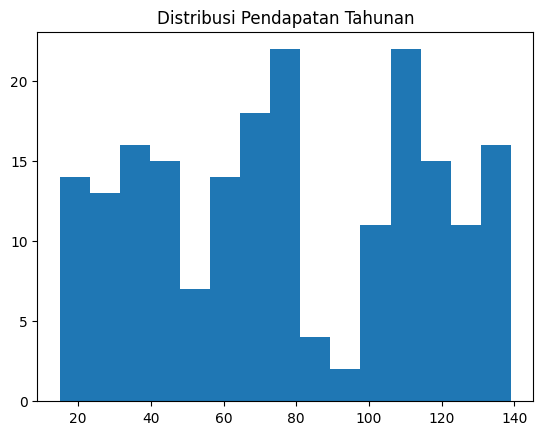

In [19]:
plt.hist(data['Annual Income (k$)'], bins=15)
plt.title('Distribusi Pendapatan Tahunan')
plt.show()

4.5 Distribusi Spending Score

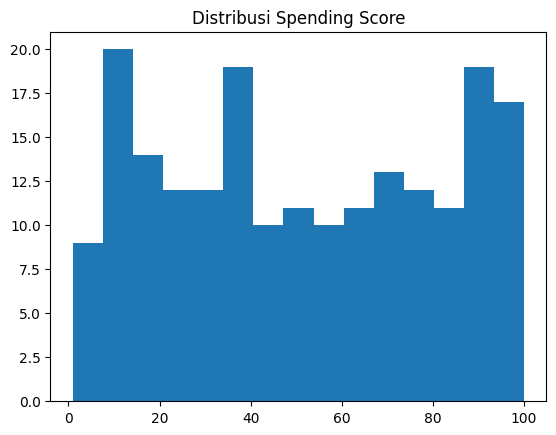

In [20]:
plt.hist(data['Spending Score (1-100)'], bins=15)
plt.title('Distribusi Spending Score')
plt.show()

4.6 Hubungan Variabel

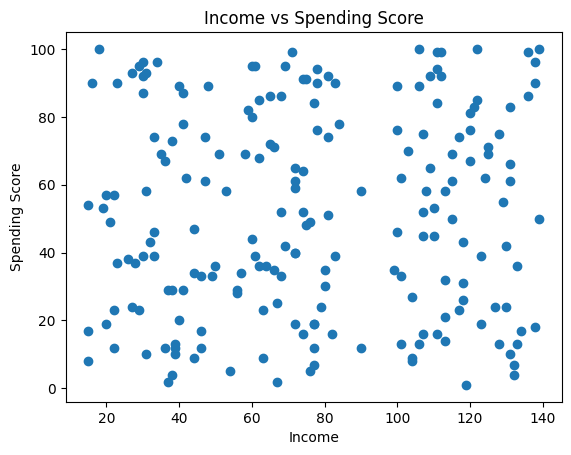

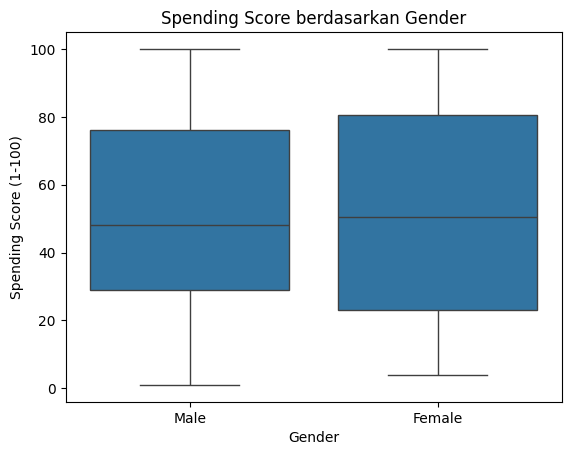

In [21]:
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('Income vs Spending Score')
plt.show()

sns.boxplot(x='Gender', y='Spending Score (1-100)', data=data)
plt.title('Spending Score berdasarkan Gender')
plt.show()

**5. Clustering Analysis**

5.1 Persiapan Data

In [22]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

5.2 Elbow Method

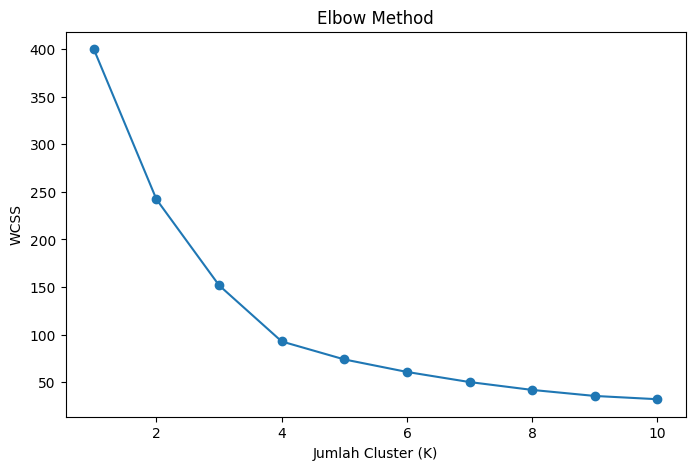

In [24]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()



5.3 Implementasi K-Means

In [25]:
kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)


data['Cluster'].value_counts()

,count
Cluster,
0,55
3,48
1,38
4,31
2,28


5.4 Visualisasi Cluster

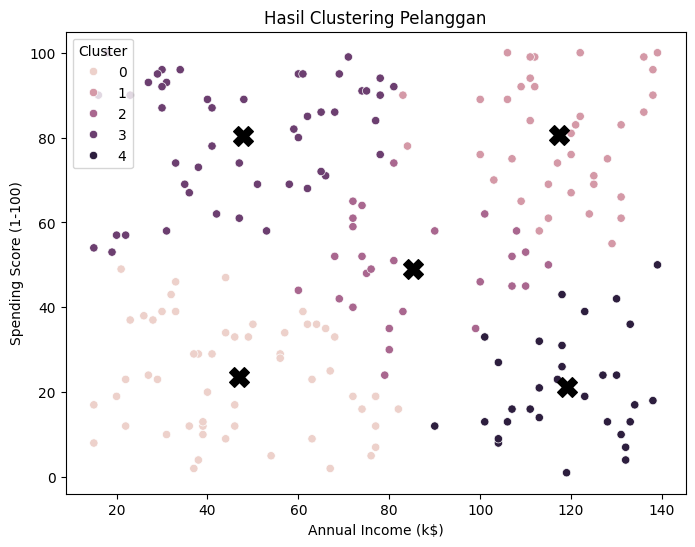

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=data)


centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1], s=200, c='black', marker='X')
plt.title('Hasil Clustering Pelanggan')
plt.show()

**6. Interpretasi Hasil**

6.1 Profil Cluster

In [28]:
cluster_profile = data.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
})

cluster_profile


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.727273,46.836364,23.490909
1,43.605263,117.368421,80.500000
2,45.535714,85.250000,49.035714
3,47.479167,47.791667,80.458333
4,42.580645,119.032258,21.096774


6.2 Nama Cluster & Rekomendasi

| Cluster | Nama Segmen          | Rekomendasi           |
| ------- | -------------------- | --------------------- |
| 0       | Low Spenders         | Diskon & promo hemat  |
| 1       | Young Shoppers       | Promo media sosial    |
| 2       | High Spenders        | VIP & loyalty program |
| 3       | Wealthy Conservative | Personal offer        |
| 4       | Average Customers    | Bundling produk       |

Setiap cluster memiliki karakteristik yang berbeda berdasarkan usia, pendapatan tahunan, dan spending score. Hal ini menunjukkan bahwa pelanggan mall dapat dikelompokkan ke dalam beberapa segmen dengan perilaku belanja yang berbeda.

**7. Evaluasi Clustering**

In [30]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    data['Cluster']
)

print("Silhouette Score:", round(score, 3))


Silhouette Score: 0.401


**Interpretasi:**  
Nilai silhouette score menunjukkan bahwa hasil clustering cukup baik dan mampu memisahkan pelanggan ke dalam segmen yang jelas.
